# Capstone 4 — Session 4: Data Visualization Techniques

**Run timestamp:** `2026-02-19 01:49:22`

## Goal
- I converted Week 3 and Week 4 analysis into required visual outputs and documented interpretation-ready findings.
- I generated and saved all required plots for categorical comparisons and correlation/relationship analysis.

## Inputs
- `NSMES1988updated.csv` from `Capstone 2/outputs/`

## Outputs
- All exports go to `./outputs/` (and plots to `./outputs/plots/` when applicable)

## Libraries (documented)
- `pandas`: I used it to prepare grouped summaries and correlation inputs for plotting.
- `matplotlib`: I used it to build and save all required charts to `outputs/plots/`.

## Key dataset note
- `age` is encoded as **Age in years (divided by 10)** (e.g., `6.9` = 69 years).

## C?-T0 — Runtime setup (paths + output folders)
I used this setup cell first to initialize reproducible paths and plotting output folders.

In [ ]:
from pathlib import Path
from datetime import datetime
from urllib.parse import quote
from urllib.request import urlretrieve
import os
import sys

try:
    from IPython.display import display as _ipy_display
except Exception:
    _ipy_display = None

def show(value):
    if _ipy_display is not None:
        _ipy_display(value)
    else:
        print(value)

# --- Project metadata ---
CAPSTONE = 4
SESSION_TITLE = 'Session 4: Data Visualization Techniques'
IS_COLAB = 'google.colab' in sys.modules
RAW_BASE = os.environ.get('FRANCISBURNET_RAW_BASE', 'https://raw.githubusercontent.com/FrancisBurnet/francisburnet/main')

print(f"Capstone: {CAPSTONE} | Session: {SESSION_TITLE}")
print("Run timestamp:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("Runtime:", "Google Colab" if IS_COLAB else "Local / notebook runtime")

CWD = Path.cwd()
if IS_COLAB:
    BASE_DIR = Path('/content/francisburnet_capstone_4')
elif (CWD / f"Capstone {CAPSTONE}").exists():
    BASE_DIR = CWD / f"Capstone {CAPSTONE}"
elif CWD.name == f"Capstone {CAPSTONE}":
    BASE_DIR = CWD
elif (CWD / "Incremental_Capstone" / f"Capstone {CAPSTONE}").exists():
    BASE_DIR = CWD / "Incremental_Capstone" / f"Capstone {CAPSTONE}"
else:
    BASE_DIR = CWD

INPUT_DIR = BASE_DIR / "inputs"
OUTPUT_DIR = BASE_DIR / "outputs"
PLOTS_DIR = OUTPUT_DIR / "plots"
INPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# --- Helpers ---
def first_existing_path(candidates):
    for candidate in candidates:
        candidate = Path(candidate).expanduser()
        if candidate.exists():
            return candidate
    return None

def github_raw_url(relative_path: str) -> str:
    normalized = relative_path.replace('\\', '/')
    return RAW_BASE.rstrip('/') + '/' + quote(normalized, safe='/')

def stage_colab_asset(relative_path: str, destination_name=None) -> Path:
    destination = INPUT_DIR / (destination_name or Path(relative_path).name)
    if not destination.exists():
        asset_url = github_raw_url(relative_path)
        urlretrieve(asset_url, destination)
        print('Downloaded:', destination.name, 'from', asset_url)
    return destination

def resolve_dataset_path(default_filename: str) -> Path:
    """Resolve dataset path from local folders or the Colab staging folder."""
    path = first_existing_path([
        INPUT_DIR / default_filename,
        BASE_DIR / default_filename,
        CWD / default_filename,
        CWD / "Incremental_Capstone" / f"Capstone {CAPSTONE}" / default_filename,
    ])
    if path is None:
        raise FileNotFoundError(f"Dataset not found: {default_filename}")
    return path

print("Base directory:", BASE_DIR)
print("Output directory:", OUTPUT_DIR)
print("Plots directory:", PLOTS_DIR)


Capstone: 4 | Session: Session 4: Data Visualization Techniques
Run timestamp: 2026-02-19 00:32:05
Output directory: c:\DEV_Projects\SIMPLILEARN\CAPSTONE_Applied_Data_Science_with _Python\Incremental_Capstone\Capstone 4\outputs
Plots directory: c:\DEV_Projects\SIMPLILEARN\CAPSTONE_Applied_Data_Science_with _Python\Incremental_Capstone\Capstone 4\outputs\plots


## C?-T1 — Imports (ONLY what you use)
I documented each import with why I used it and what it enabled in this capstone.

In [10]:
import pandas as pd  # DataFrames + aggregation/pivot/correlation preparation
import matplotlib.pyplot as plt  # Plot creation and export to outputs/plots

## C?-T2 — Load dataset
I loaded the instructed handoff dataset from Capstone 2 using default + fallback paths.

In [ ]:
DEFAULT_DATASET = "NSMES1988updated.csv"

try:
    dataset_path = resolve_dataset_path(DEFAULT_DATASET)
except FileNotFoundError:
    fallback = first_existing_path([
        BASE_DIR.parent / "Capstone 2" / "outputs" / "NSMES1988updated.csv",
        CWD / "Capstone 2" / "outputs" / "NSMES1988updated.csv",
        CWD / "Incremental_Capstone" / "Capstone 2" / "outputs" / "NSMES1988updated.csv",
    ])
    if fallback is None and IS_COLAB:
        fallback = stage_colab_asset(
            'Incremental Capstones/Applied Data Science with Python/Capstone 2/outputs/NSMES1988updated.csv'
        )
    if fallback is None:
        raise
    dataset_path = fallback
    print("Local default not found; using fallback:", dataset_path)

df = pd.read_csv(dataset_path)
if "age_years" not in df.columns and "age" in df.columns:
    df["age_years"] = (df["age"] * 10).round(0)
if "income_dollars" not in df.columns and "income" in df.columns:
    df["income_dollars"] = (df["income"] * 10000).round(0)

print("Loaded:", dataset_path)
print("Shape:", df.shape)
show(df.head())


Local default not found; using fallback: c:\DEV_Projects\SIMPLILEARN\CAPSTONE_Applied_Data_Science_with _Python\Incremental_Capstone\Capstone 2\outputs\NSMES1988updated.csv
Loaded: c:\DEV_Projects\SIMPLILEARN\CAPSTONE_Applied_Data_Science_with _Python\Incremental_Capstone\Capstone 2\outputs\NSMES1988updated.csv
Shape: (4406, 20)


,visits,nvisits,ovisits,novisits,emergency,hospital,health,chronic,adl,region,age,gender,married,school,income,employed,insurance,medicaid,age_years,income_dollars
0,5,0,0,0,0,1,average,2,normal,other,6.9,male,yes,6,2.8810,yes,yes,no,69,28810
1,1,0,2,0,2,0,average,2,normal,other,7.4,female,yes,10,2.7478,no,yes,no,74,27478
2,13,0,0,0,3,3,poor,4,limited,other,6.6,female,no,10,0.6532,no,no,yes,66,6532
3,16,0,5,0,1,1,poor,2,limited,other,7.6,male,yes,3,0.6588,no,yes,no,76,6588
4,3,0,0,0,0,0,average,2,limited,other,7.9,female,yes,6,0.6588,no,yes,no,79,6588


## C?-T3 — Validation checks
- Confirm expected columns exist
- Confirm key dtypes
- Check missing values

**Results Capture:**
- What I did: I validated expected schema/dtypes and checked missing values prior to plotting.
- What I found: shape=`(4406, 20)` and no missing values; plotting fields required for tasks are available.
- Caveats: derived pairs (`age` vs `age_years`, `income` vs `income_dollars`) naturally dominate top correlation rankings.

In [12]:
expected_cols = [
    "visits", "nvisits", "ovisits", "novisits", "emergency", "hospital",
    "health", "chronic", "adl", "region", "age", "gender",
    "married", "school", "income", "employed", "insurance", "medicaid",
    "age_years", "income_dollars"
]

missing_cols = [c for c in expected_cols if c not in df.columns]
print("Missing expected columns:", missing_cols)

print("\nDtypes:")
show(df.dtypes)

print("\nMissing values (count):")
na_counts = df.isna().sum().sort_values(ascending=False)
show(na_counts[na_counts > 0] if (na_counts > 0).any() else na_counts.head())


Missing expected columns: []

Dtypes:


visits              int64
nvisits             int64
ovisits             int64
novisits            int64
emergency           int64
hospital            int64
health                str
chronic             int64
adl                   str
region                str
age               float64
gender                str
married               str
school              int64
income            float64
employed              str
insurance             str
medicaid              str
age_years           int64
income_dollars      int64
dtype: object


Missing values (count):


visits       0
nvisits      0
ovisits      0
novisits     0
emergency    0
dtype: int64

## C4-T3 — State plotting library choice + reasons
**PDF requirement:** State which library you used for plotting and why.

### What I completed
- I used Matplotlib for all required visualizations and file exports.

### Results Capture
- Library choice: **Matplotlib**.
- Reasons: strong pandas compatibility, clear customization, and straightforward PNG export to `outputs/plots/`.

### Code evidence
- The next cell prints the plotting-library choice summary used in this submission.

In [13]:
print("Plotting library: matplotlib")
print("Reason: direct pandas compatibility, flexible formatting, and reliable PNG export for grading artifacts.")


Plotting library: matplotlib
Reason: direct pandas compatibility, flexible formatting, and reliable PNG export for grading artifacts.


## C4-T4 — Plot Week 3 categorical analysis for Health and Region
**PDF requirement:** Plot the Week 3 categorical analysis for Health and Region.

### What I completed
- I transformed Week 3 category analysis into saved bar-chart visualizations for region and health, plus a grouped region-health visits chart.

### Results Capture
- Saved plot artifacts:
  - `outputs/plots/region_counts.png`
  - `outputs/plots/health_counts.png`
  - `outputs/plots/mean_visits_region_health.png`
- Interpretation highlights:
  - `other` region has the largest count, while `west` has the smallest.
  - `average` health status dominates the sample compared with `excellent` and `poor`.
  - Mean visits vary across region-health segments.

### Artifacts
- `outputs/plots/region_counts.png (example)`
- `outputs/plots/health_*.png`

### Code evidence
- The next cell contains all categorical plotting commands I ran and saved.

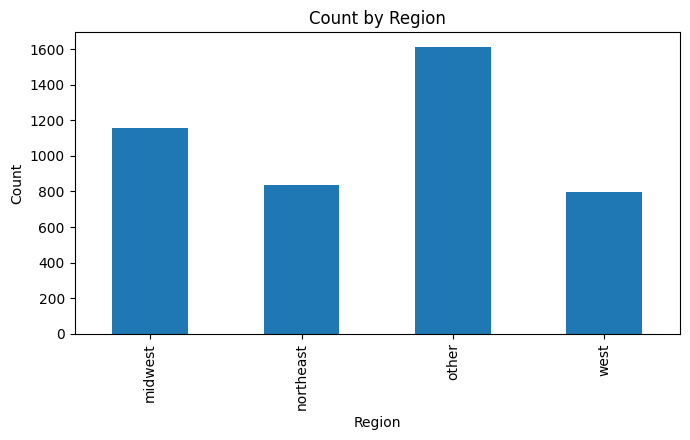

Saved: c:\DEV_Projects\SIMPLILEARN\CAPSTONE_Applied_Data_Science_with _Python\Incremental_Capstone\Capstone 4\outputs\plots\region_counts.png


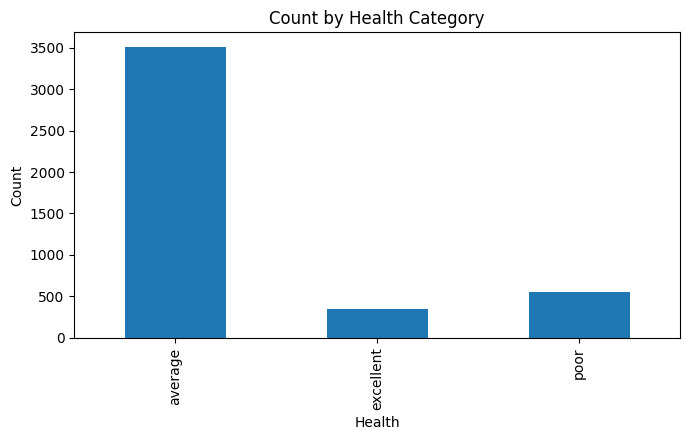

Saved: c:\DEV_Projects\SIMPLILEARN\CAPSTONE_Applied_Data_Science_with _Python\Incremental_Capstone\Capstone 4\outputs\plots\health_counts.png


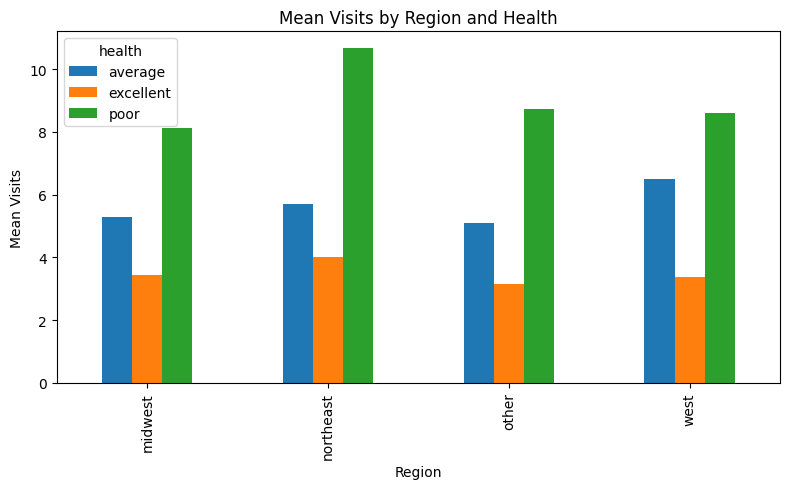

Saved: c:\DEV_Projects\SIMPLILEARN\CAPSTONE_Applied_Data_Science_with _Python\Incremental_Capstone\Capstone 4\outputs\plots\mean_visits_region_health.png


In [14]:
# Plot 1: counts by region
if "region" in df.columns:
    region_counts = df["region"].value_counts()
    fig, ax = plt.subplots(figsize=(7, 4.5))
    region_counts.sort_index().plot(kind="bar", title="Count by Region", ax=ax)
    ax.set_xlabel("Region")
    ax.set_ylabel("Count")
    out = PLOTS_DIR / "region_counts.png"
    fig.tight_layout()
    fig.savefig(out, dpi=150)
    plt.show()
    print("Saved:", out)

# Plot 2: counts by health
if "health" in df.columns:
    fig, ax = plt.subplots(figsize=(7, 4.5))
    df["health"].value_counts().sort_index().plot(kind="bar", title="Count by Health Category", ax=ax)
    ax.set_xlabel("Health")
    ax.set_ylabel("Count")
    out = PLOTS_DIR / "health_counts.png"
    fig.tight_layout()
    fig.savefig(out, dpi=150)
    plt.show()
    print("Saved:", out)

# Plot 3: mean visits by region and health
if set(["region", "health", "visits"]).issubset(df.columns):
    pivot_visits = pd.pivot_table(df, index="region", columns="health", values="visits", aggfunc="mean")
    fig, ax = plt.subplots(figsize=(8, 5))
    pivot_visits.plot(kind="bar", ax=ax)
    ax.set_title("Mean Visits by Region and Health")
    ax.set_xlabel("Region")
    ax.set_ylabel("Mean Visits")
    out = PLOTS_DIR / "mean_visits_region_health.png"
    fig.tight_layout()
    fig.savefig(out, dpi=150)
    plt.show()
    print("Saved:", out)


## C4-T5 — Plot Week 4 analysis + correlation
**PDF requirement:** Plot Week 4 analysis and correlation. Provide detailed report and observations.

### What I completed
- I computed numeric correlations, exported a correlation-matrix figure, and generated required scatter plots for key relationships.

### Results Capture
- Correlation highlights: `emergency~hospital=0.476`, `ovisits~novisits=0.467`, `visits~chronic=0.262`.
- Derived pairs `age~age_years` and `income~income_dollars` reached `1.0` as expected.
- Saved artifacts: `correlation_matrix.png`, `scatter_income_vs_visits.png`, `scatter_age_vs_visits.png`, `scatter_income_vs_emergency.png`.

### Artifacts
- `outputs/plots/correlation_matrix.png`
- `outputs/plots/scatter_*.png`

### Code evidence
- The next cell contains all correlation and scatter plotting commands I executed.

,visits,nvisits,ovisits,novisits,emergency,hospital,chronic,age,school,income,age_years,income_dollars
visits,1.000000,0.226365,0.068144,0.078468,0.158748,0.240789,0.261886,0.003404,0.064433,-0.004951,0.003404,-0.004951
nvisits,0.226365,1.000000,0.001129,0.041768,0.049056,0.050401,0.037113,-0.041640,0.085974,0.010731,-0.041640,0.010731
ovisits,0.068144,0.001129,1.000000,0.466923,0.065388,0.110573,0.100805,-0.040028,-0.012156,-0.004267,-0.040028,-0.004267
novisits,0.078468,0.041768,0.466923,1.000000,0.024083,0.065301,0.040748,-0.032813,-0.011733,-0.007786,-0.032813,-0.007786
emergency,0.158748,0.049056,0.065388,0.024083,1.000000,0.476061,0.203845,0.061023,-0.071192,-0.026462,0.061023,-0.026462
hospital,0.240789,0.050401,0.110573,0.065301,0.476061,1.000000,0.233524,0.074122,-0.036082,-0.014183,0.074122,-0.014183
chronic,0.261886,0.037113,0.100805,0.040748,0.203845,0.233524,1.000000,0.099758,-0.065829,-0.047397,0.099758,-0.047397
age,0.003404,-0.041640,-0.040028,-0.032813,0.061023,0.074122,0.099758,1.000000,-0.142996,-0.073130,1.000000,-0.073130
school,0.064433,0.085974,-0.012156,-0.011733,-0.071192,-0.036082,-0.065829,-0.142996,1.000000,0.259199,-0.142996,0.259199
income,-0.004951,0.010731,-0.004267,-0.007786,-0.026462,-0.014183,-0.047397,-0.073130,0.259199,1.000000,-0.073130,1.000000


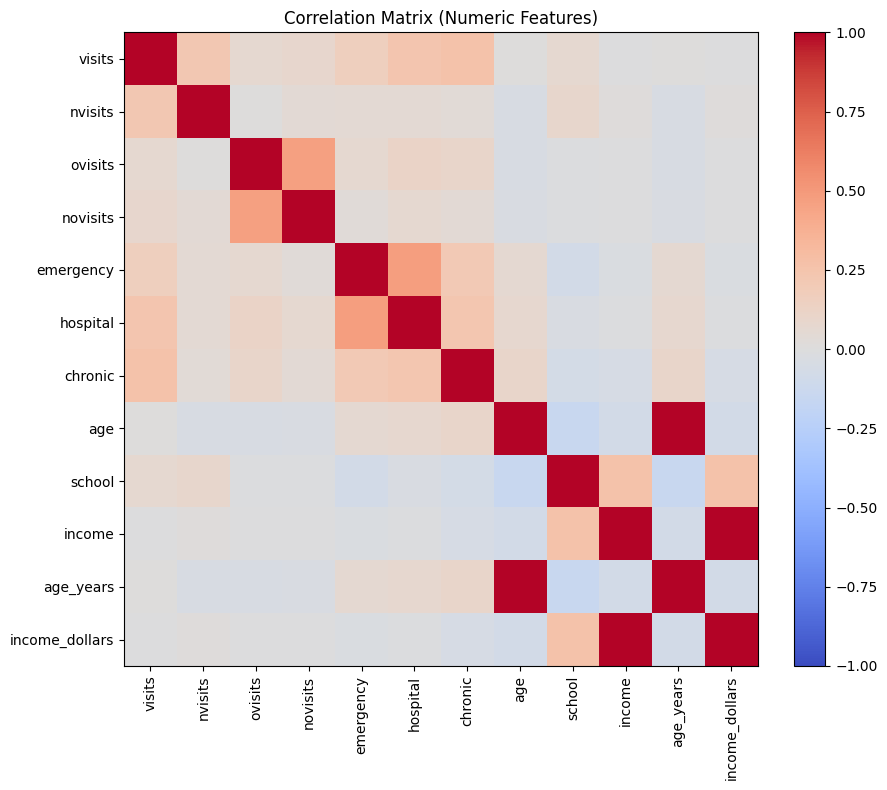

Saved: c:\DEV_Projects\SIMPLILEARN\CAPSTONE_Applied_Data_Science_with _Python\Incremental_Capstone\Capstone 4\outputs\plots\correlation_matrix.png


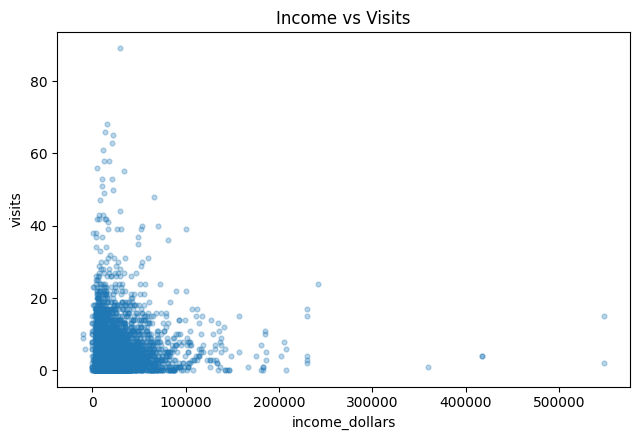

Saved: c:\DEV_Projects\SIMPLILEARN\CAPSTONE_Applied_Data_Science_with _Python\Incremental_Capstone\Capstone 4\outputs\plots\scatter_income_vs_visits.png


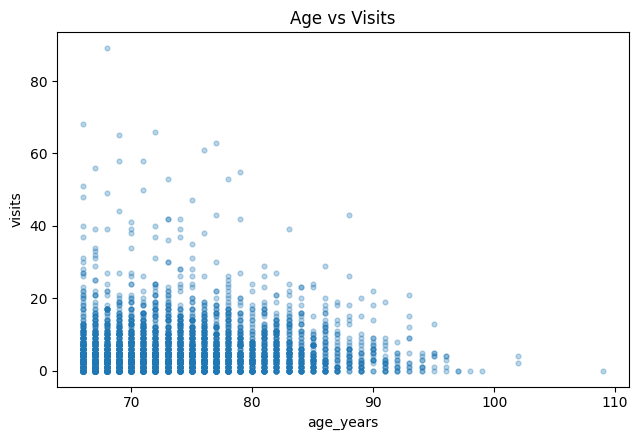

Saved: c:\DEV_Projects\SIMPLILEARN\CAPSTONE_Applied_Data_Science_with _Python\Incremental_Capstone\Capstone 4\outputs\plots\scatter_age_vs_visits.png


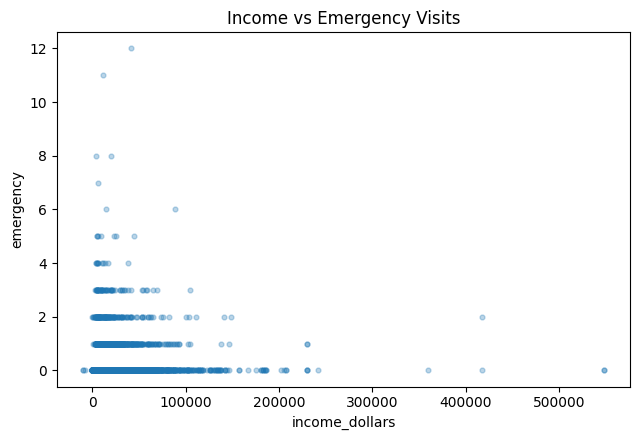

Saved: c:\DEV_Projects\SIMPLILEARN\CAPSTONE_Applied_Data_Science_with _Python\Incremental_Capstone\Capstone 4\outputs\plots\scatter_income_vs_emergency.png


In [15]:
num_df = df.select_dtypes(include=["number"])
corr = num_df.corr(numeric_only=True)
show(corr)

fig, ax = plt.subplots(figsize=(10, 8))
cax = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
fig.colorbar(cax, ax=ax, fraction=0.046, pad=0.04)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)
ax.set_title("Correlation Matrix (Numeric Features)")

out = PLOTS_DIR / "correlation_matrix.png"
fig.tight_layout()
fig.savefig(out, bbox_inches="tight", dpi=150)
plt.show()
print("Saved:", out)

scatter_specs = [
    ("income_dollars", "visits", "scatter_income_vs_visits.png", "Income vs Visits"),
    ("age_years", "visits", "scatter_age_vs_visits.png", "Age vs Visits"),
    ("income_dollars", "emergency", "scatter_income_vs_emergency.png", "Income vs Emergency Visits")
]

for x, y, fname, title in scatter_specs:
    if x in df.columns and y in df.columns:
        fig, ax = plt.subplots(figsize=(6.5, 4.5))
        ax.scatter(df[x], df[y], alpha=0.3, s=12)
        ax.set_title(title)
        ax.set_xlabel(x)
        ax.set_ylabel(y)
        out = PLOTS_DIR / fname
        fig.tight_layout()
        fig.savefig(out, dpi=150)
        plt.show()
        print("Saved:", out)


## Final section — Conclusions (required)
- I completed the required visualization deliverables using the instructed Capstone 2 handoff dataset.
- I produced and interpreted categorical analysis charts for health and region.
- I delivered correlation and scatter-relationship visuals with caveats documented for derived-feature pairs.
- I saved all grading artifacts under `outputs/plots/` and updated `WORK_SUMMARY.md` accordingly.


In [16]:
print("Capstone 4 completed: C4-T3 to C4-T5")
print("Artifacts saved under outputs/plots")


Capstone 4 completed: C4-T3 to C4-T5
Artifacts saved under outputs/plots
